<a href="https://colab.research.google.com/github/rcarvalhoo/Git_e_GitHub/blob/main/Estudo_rede_basica_CETESB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [4]:
# Passo 2 - Carregando os dados
df = pd.read_csv("PONTOS_REDE_BASICA_QASUPER.csv", sep=';', encoding='latin1')
df.head()

,CodInterAguas,TipoRede,UGRHI,CodPonto,SistHidrico,TipoSistHidrico,Classe,Municipio,UF,Localizacao,LongDecml,LattDecml
0,77,Rede Básica,05 - PIRACICABA/CAPIVARI/JUNDIAI,JUNA03900,Rio Jundiaí - UGRHI 05 - JUNA,Rio (Lótico),Classe 3,SALTO,SP,"Ponte na Praça Álvaro Guião, na área urbana de...","-47,29111111","-23,21"
1,100,Rede Básica,06 - ALTO TIÊTE,COGR00900,Reservatório das Graças - COGR,Reservatório (Lêntico),Classe Especial,COTIA,SP,"Na barragem, junto à captação do Alto Cotia","-46,9675","-23,65333333"
2,106,Rede Básica,06 - ALTO TIÊTE,GUAR00900,Reservatório do Guarapiranga - GUAR,Reservatório (Lêntico),Classe Especial,SÃO PAULO,SP,Na Captação da SABESP junto à casa de Bombas.,"-46,72777778","-23,67416667"
3,119,Rede Básica,06 - ALTO TIÊTE,JQJU00900,Reservatório do Juqueri ou Paiva Castro - JQJU,Reservatório (Lêntico),Classe Especial,MAIRIPORA,SP,"Ponte Santa Inês, na rodovia que liga Mairipor...","-46,6625","-23,34027778"
4,120,Rede Básica,06 - ALTO TIÊTE,TAMT04900,Rio Tamanduateí - TAMT,Rio (Lótico),Classe 4,SÃO PAULO,SP,"Ponte na Av. Santos Dumont, em frente à Secret...","-46,63222222","-23,52666667"


In [5]:
# Verificando as colunas
df.columns

Index(['CodInterAguas', 'TipoRede', 'UGRHI', 'CodPonto', 'SistHidrico',
       'TipoSistHidrico', 'Classe', 'Municipio', 'UF', 'Localizacao',
       'LongDecml', 'LattDecml'],
      dtype='object')

In [6]:
# Renomeando colunas para facilitar o uso
df.columns = ['codigo', 'tipo_rede', 'ugrhi', 'cod_ponto', 'sistema_hidrico',
              'tipo_sistema', 'classe', 'municipio', 'uf', 'localizacao',
              'longitude', 'latitude']

# Verificando tipos de dados e valores ausentes
print(df.info())
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

# Removendo linhas com coordenadas faltando (se houver)
df = df.dropna(subset=['longitude', 'latitude'])

# Padronizando nomes dos municípios para análise
df['municipio'] = df['municipio'].str.strip().str.upper()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   codigo           679 non-null    int64 
 1   tipo_rede        679 non-null    object
 2   ugrhi            679 non-null    object
 3   cod_ponto        679 non-null    object
 4   sistema_hidrico  679 non-null    object
 5   tipo_sistema     679 non-null    object
 6   classe           679 non-null    object
 7   municipio        679 non-null    object
 8   uf               679 non-null    object
 9   localizacao      679 non-null    object
 10  longitude        674 non-null    object
 11  latitude         674 non-null    object
dtypes: int64(1), object(11)
memory usage: 63.8+ KB
None

Valores ausentes por coluna:
codigo             0
tipo_rede          0
ugrhi              0
cod_ponto          0
sistema_hidrico    0
tipo_sistema       0
classe             0
municipio          0
uf        

<ipython-input-6-934d134edc1c>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['municipio'] = df['municipio'].str.strip().str.upper()


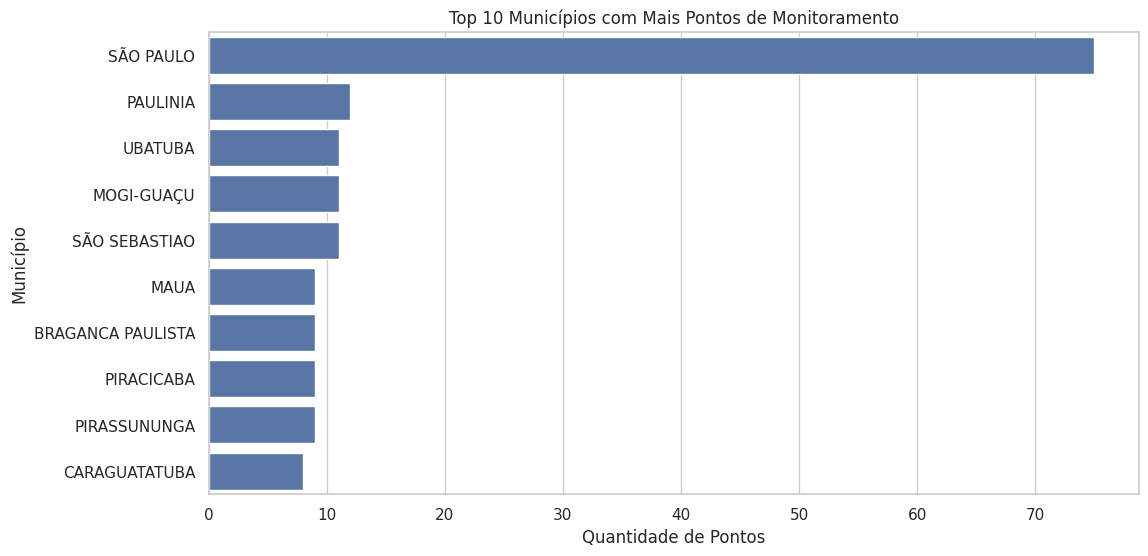

In [7]:
# Contagem de pontos por município
df_municipios = df['municipio'].value_counts().reset_index()
df_municipios.columns = ['Município', 'Total de Pontos']

# Gráfico de barras
sns.barplot(data=df_municipios.head(10), x='Total de Pontos', y='Município')
plt.title('Top 10 Municípios com Mais Pontos de Monitoramento')
plt.xlabel('Quantidade de Pontos')
plt.ylabel('Município')
plt.show()

Estudando as praias

In [8]:
# Carregando o CSV
df = pd.read_csv("praias_litoral_sp.csv")
df.head()

,Praia,Município,Tipo,Avaliação (1-5),Latitude,Longitude
0,Praia de Maresias,São Sebastião,Surf,3.7,-24.739605,-46.210004
1,Praia de Juquehy,São Sebastião,Familiar,4.9,-24.428553,-45.828278
2,Praia de Ubatumirim,Ubatuba,Selvagem,4.5,-23.664208,-45.436739
3,Praia do Tombo,Guarujá,Surf,3.9,-24.992423,-45.492637
4,Praia de Boraceia,Bertioga,Familiar,4.7,-24.694684,-45.550039


# Avaliação média por município

<ipython-input-9-f363b3e74096>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avaliacao_municipio, x="Avaliação (1-5)", y="Município", palette="viridis")


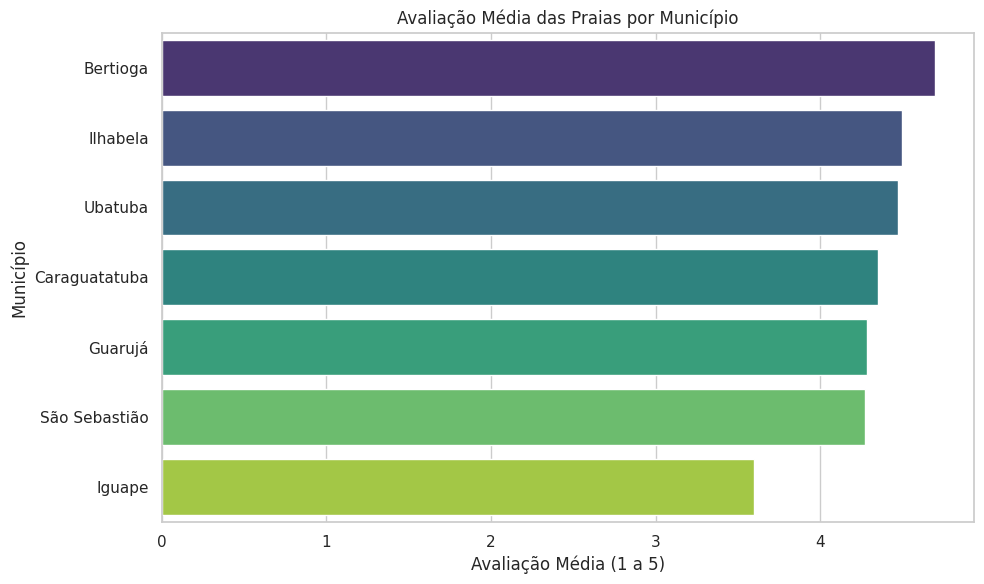

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo bonito
sns.set(style="whitegrid")

# Agrupando por município
avaliacao_municipio = df.groupby("Município")["Avaliação (1-5)"].mean().sort_values(ascending=False).reset_index()

# Gráfico
plt.figure(figsize=(10,6))
sns.barplot(data=avaliacao_municipio, x="Avaliação (1-5)", y="Município", palette="viridis")
plt.title("Avaliação Média das Praias por Município")
plt.xlabel("Avaliação Média (1 a 5)")
plt.ylabel("Município")
plt.tight_layout()
plt.show()

# Quantidade de praias por tipo

<ipython-input-10-f91bac148960>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Tipo", order=df["Tipo"].value_counts().index, palette="coolwarm")


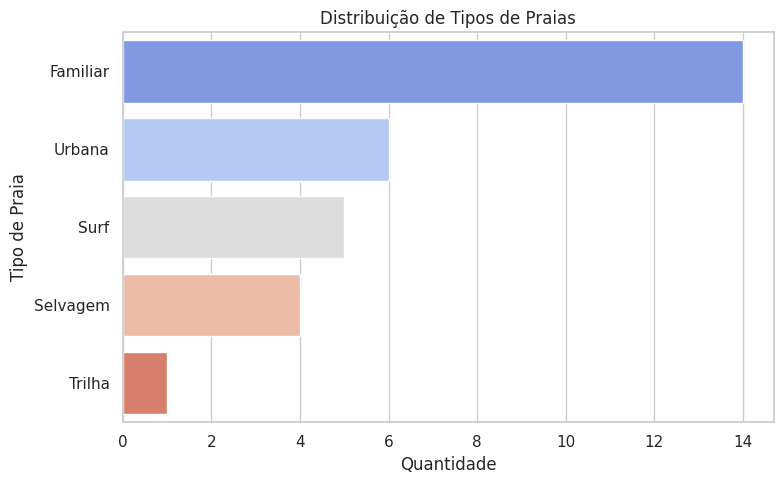

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Tipo", order=df["Tipo"].value_counts().index, palette="coolwarm")
plt.title("Distribuição de Tipos de Praias")
plt.xlabel("Quantidade")
plt.ylabel("Tipo de Praia")
plt.tight_layout()
plt.show()

# Top 10 praias mais bem avaliadas

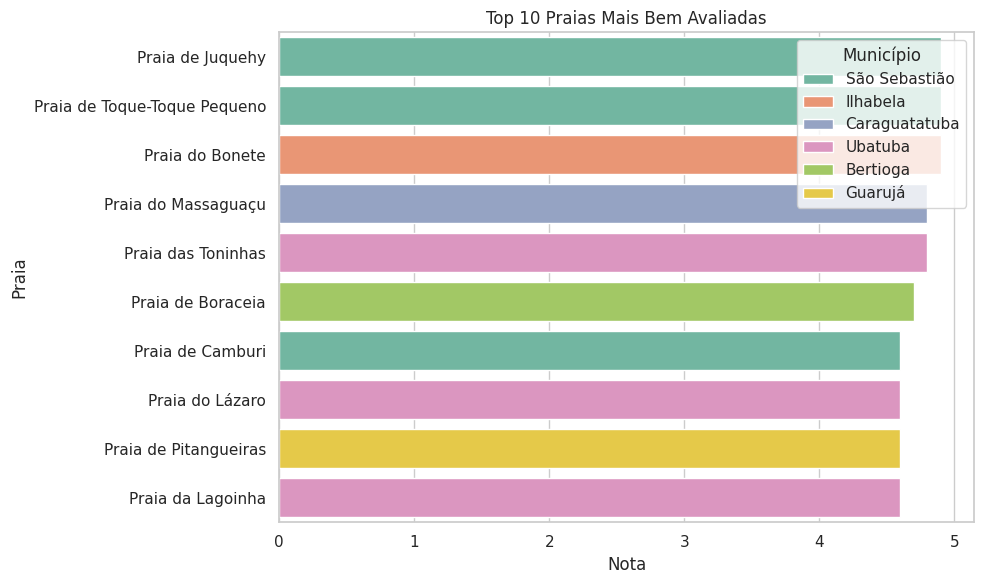

In [12]:
top10 = df.sort_values("Avaliação (1-5)", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="Avaliação (1-5)", y="Praia", hue="Município", dodge=False, palette="Set2")
plt.title("Top 10 Praias Mais Bem Avaliadas")
plt.xlabel("Nota")
plt.ylabel("Praia")
plt.tight_layout()
plt.show()

# TOP 10

In [14]:
!pip install folium

# Criando o mapa com marcadores

In [15]:
import folium

# Criar um mapa centrado aproximadamente no litoral de SP
mapa = folium.Map(location=[-23.8, -45.4], zoom_start=8)

# Adicionar marcadores para cada praia
for _, row in df.iterrows():
    popup_text = f"<b>{row['Praia']}</b><br>Município: {row['Município']}<br>Nota: {row['Avaliação (1-5)']}"
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=popup_text,
        tooltip=row["Praia"],
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(mapa)

# Exibir
mapa

# Ajustando a localização

In [16]:
import pandas as pd

# Dados reais de algumas praias
dados_praias = {
    "Praia": [
        "Praia de Maresias", "Praia de Juquehy", "Praia de Ubatumirim",
        "Praia do Tombo", "Praia de Boraceia", "Praia do Félix",
        "Praia do Guaiúba", "Praia de Itamambuca", "Praia da Enseada",
        "Praia da Juréia"
    ],
    "Município": [
        "São Sebastião", "São Sebastião", "Ubatuba",
        "Guarujá", "Bertioga", "Ubatuba",
        "Guarujá", "Ubatuba", "Guarujá",
        "Iguape"
    ],
    "Tipo": [
        "Surf", "Familiar", "Selvagem",
        "Surf", "Familiar", "Selvagem",
        "Familiar", "Surf", "Urbana",
        "Selvagem"
    ],
    "Avaliação (1-5)": [4.8, 4.6, 4.7, 4.5, 4.4, 4.9, 4.3, 4.7, 4.2, 4.1],
    "Latitude": [
        -23.7789, -23.7850, -23.3950,
        -24.0000, -23.7150, -23.4300,
        -23.9930, -23.4220, -23.9860,
        -24.6580
    ],
    "Longitude": [
        -45.5374, -45.6820, -45.1000,
        -46.2560, -46.1380, -45.0500,
        -46.2560, -45.0500, -46.2560,
        -47.5630
    ]
}

# Criar DataFrame
df_praias_reais = pd.DataFrame(dados_praias)

In [17]:
import folium

# Criar o mapa centrado no litoral de São Paulo
mapa = folium.Map(location=[-23.9, -45.3], zoom_start=8)

# Adicionar marcadores para cada praia
for _, row in df_praias_reais.iterrows():
    popup_text = f"<b>{row['Praia']}</b><br>Município: {row['Município']}<br>Tipo: {row['Tipo']}<br>Avaliação: {row['Avaliação (1-5)']}"
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=popup_text,
        tooltip=row["Praia"],
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(mapa)

# Exibir o mapa
mapa

In [18]:
import pandas as pd

# Criar um novo DataFrame com as coordenadas reais
dados_reais = {
    "Praia": [
        "Praia de Maresias", "Praia de Juquehy", "Praia de Ubatumirim",
        "Praia do Tombo", "Praia de Boraceia", "Praia do Félix",
        "Praia do Guaiúba", "Praia de Itamambuca", "Praia da Enseada",
        "Praia da Juréia"
    ],
    "Município": [
        "São Sebastião", "São Sebastião", "Ubatuba",
        "Guarujá", "Bertioga", "Ubatuba",
        "Guarujá", "Ubatuba", "Guarujá",
        "Iguape"
    ],
    "Tipo": [
        "Surf", "Familiar", "Selvagem",
        "Surf", "Familiar", "Selvagem",
        "Familiar", "Surf", "Urbana",
        "Selvagem"
    ],
    "Avaliação (1-5)": [4.8, 4.6, 4.7, 4.5, 4.4, 4.9, 4.3, 4.7, 4.2, 4.1],
    "Latitude": [
        -23.7789, -23.7850, -23.3950,
        -24.0000, -23.7150, -23.4300,
        -23.9930, -23.4220, -23.9860,
        -24.6580
    ],
    "Longitude": [
        -45.5374, -45.6820, -45.1000,
        -46.2560, -46.1380, -45.0500,
        -46.2560, -45.0500, -46.2560,
        -47.5630
    ]
}

df_praias_reais = pd.DataFrame(dados_reais)

In [19]:
mapa